<a href="https://colab.research.google.com/github/bintanghan07/data-science-2026/blob/main/Pertemuan9_BintangHanifatulManunggal_250401020095.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAKTIKUM PERTEMUAN 9 DATA SCIENCE**

Nama : Bintang Hanifatul Manunggal

Nim :  250401020095

Kelas : IF405

### **1. Langkah 1: Load & EDA Singkat**

In [5]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
cancer = load_breast_cancer()

# Membentuk dataframe fitur dan target
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(cancer.target)

print("Jumlah data dan fitur :", X.shape)

Jumlah data dan fitur : (569, 30)


In [6]:
# Melihat proporsi masing-masing kelas
kelas = y.replace({
    0: "Malignant",
    1: "Benign"
})

distribusi = (
    kelas.value_counts(normalize=True)
    .round(3)
)

print("Distribusi kelas:")
print(distribusi)



Distribusi kelas:
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


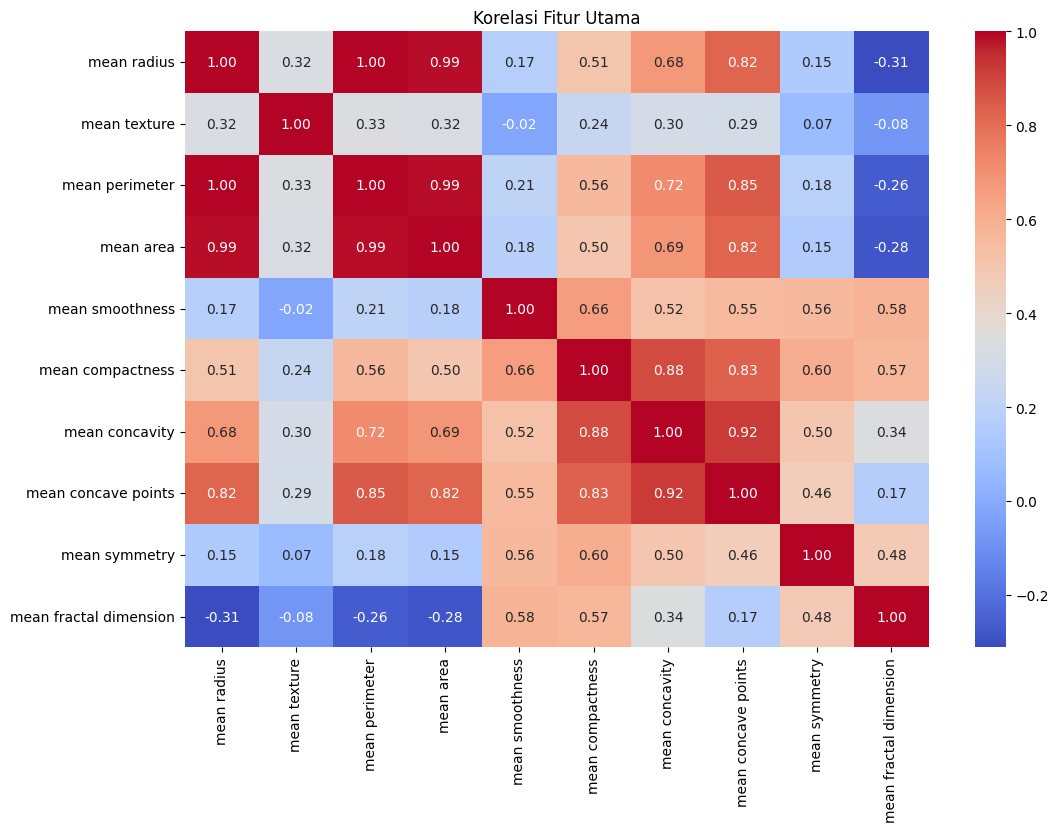

In [7]:
# Menampilkan korelasi beberapa fitur utama
plt.figure(figsize=(12, 8))

sns.heatmap(
    X.iloc[:, :10].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Fitur Utama")
plt.show()

Dataset Breast Cancer Wisconsin berhasil dimuat menggunakan load_breast_cancer() dari library scikit-learn. Dataset ini mempunyai 569 data dengan 30 fitur yang digunakan untuk mengklasifikasikan jenis tumor payudara.

Variabel target terdiri dari dua kelas, yaitu 0 = Malignant (ganas) dan 1 = Benign (jinak). Berdasarkan distribusi target, sekitar 37,3% data termasuk kelas malignant, sedangkan sekitar 62,7% termasuk kelas benign. Hal ini menunjukkan bahwa jumlah data pada kelas benign lebih banyak dibandingkan kelas malignant, sehingga perlu diperhatikan saat proses analisis atau pembangunan model klasifikasi.

### **2. Langkah 2: Preprocessing**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# standardisasi fitur
scaler = StandardScaler()

# Fit scaler pada data latih, lalu transform data latih
X_train_s = scaler.fit_transform(X_train)

# Transform data uji menggunakan scaler yang sama
X_test_s = scaler.transform(X_test)

# Menampilkan hasil
print("Jumlah data latih :", X_train.shape)
print("Jumlah data uji   :", X_test.shape)

print("\nDistribusi target data latih:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi target data uji:")
print(pd.Series(y_test).value_counts())

Jumlah data latih : (455, 30)
Jumlah data uji   : (114, 30)

Distribusi target data latih:
1    285
0    170
Name: count, dtype: int64

Distribusi target data uji:
1    72
0    42
Name: count, dtype: int64


Pada tahap ini dilakukan pembagian dataset menjadi 80% data latih (455 data) dan 20% data uji (114 data)menggunakan metode Train-Test Split.

Parameter stratify=y digunakan untuk mempertahankan proporsi kelas malignant (0) dan benign (1) pada data latih maupun data uji sehingga distribusi kelas tetap seimbang seperti pada dataset asli.

Setelah itu, dilakukan standardisasi fitur untuk mengubah nilai setiap fitur agar memiliki rata-rata 0 dan standar deviasi 1. kemudian diterapkan pada data uji (transform) untuk menghindari data leakage.

### **3. Langkah 3: Latih Logistic Regression**

In [9]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Membuat model Logistic Regression
log_model = LogisticRegression(max_iter=5000)

# Melatih model
log_model.fit(X_train_s, y_train)

# Melakukan prediksi pada data uji
y_pred_log = log_model.predict(X_test_s)

# Menampilkan koefisien setiap fitur
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
}).sort_values(
    by="Koefisien",
    key=abs,
    ascending=False
)

# Menampilkan 10 fitur dengan pengaruh terbesar
print("10 Fitur dengan Koefisien Terbesar:")
print(coef_df.head(10))

10 Fitur dengan Koefisien Terbesar:
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616
28        worst symmetry  -0.939181
13            area error  -0.929104
26       worst concavity  -0.823151
22       worst perimeter  -0.763220
24      worst smoothness  -0.746625


Pada tahap ini, model Logistic Regression dilatih menggunakan data latih yang telah melalui proses standardisasi. Setelah model berhasil dilatih, dilakukan prediksi terhadap data uji untuk mengetahui hasil klasifikasi.

Selanjutnya, nilai koefisien dari setiap fitur ditampilkan untuk melihat seberapa besar pengaruh masing-masing fitur terhadap prediksi model. Fitur dengan nilai koefisien absolut (|koefisien|) terbesar merupakan fitur yang paling berpengaruh dalam menentukan apakah suatu tumor diklasifikasikan sebagai malignant (ganas) atau benign (jinak).

Tanda positif pada koefisien menunjukkan bahwa peningkatan nilai fitur cenderung mengarah pada kelas benign (1), sedangkan tanda negatif menunjukkan kecenderungan mengarah pada kelas malignant (0). Dengan demikian, analisis koefisien dapat membantu memahami faktor-faktor yang paling memengaruhi keputusan model.

### **4. Langkah 4: Latih Decision Tree**

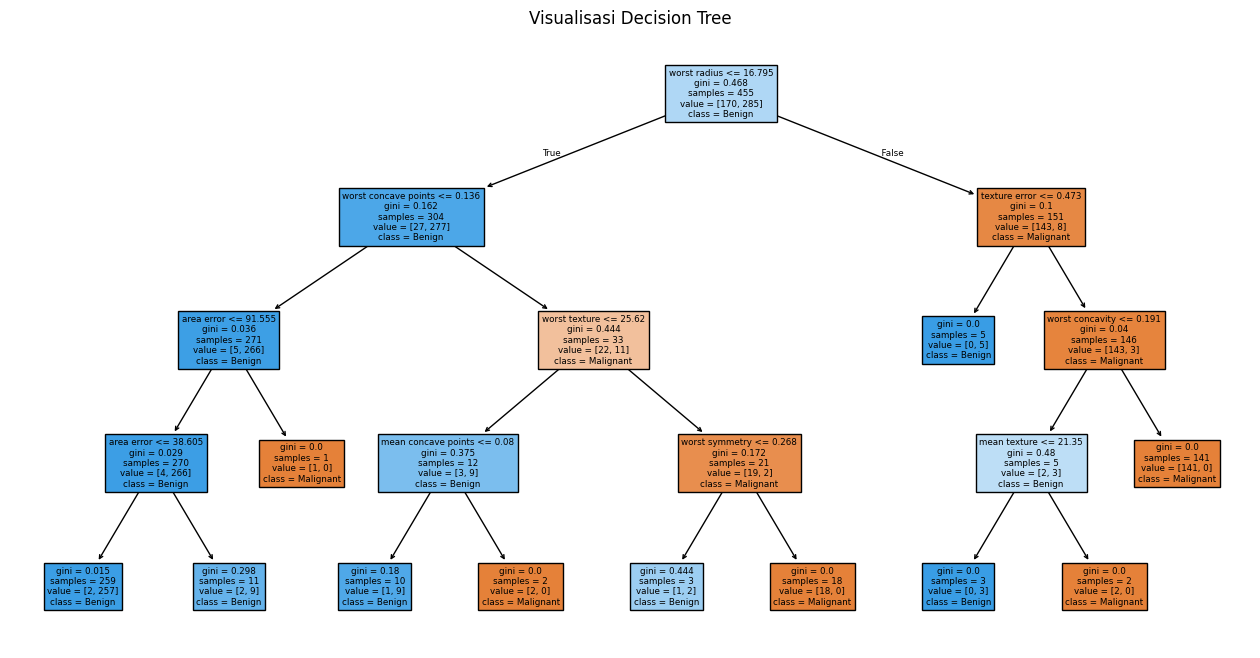

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Membuat model Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Melatih model menggunakan data asli (tanpa standardisasi)
tree_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred_tree = tree_model.predict(X_test)

# Visualisasi Decision Tree
plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True
)

plt.title("Visualisasi Decision Tree")
plt.show()

Berdasarkan hasil visualisasi Decision Tree, fitur worst radius menjadi faktor utama yang digunakan untuk membedakan tumor malignant dan benign.

Selanjutnya, model menggunakan beberapa fitur lain seperti worst concave points, texture error, worst texture, dan worst concavity untuk membuat keputusan pada setiap percabangan.

Sebagian besar data berhasil dikelompokkan dengan baik, terlihat dari banyaknya node yang memiliki nilai gini = 0, yang menunjukkan bahwa data pada node tersebut sudah termasuk dalam satu kelas. Dengan batas kedalaman pohon (max_depth = 4), model tetap mudah dipahami dan mampu menunjukkan proses klasifikasi secara jelas tanpa menghasilkan pohon yang terlalu kompleks.

### **5. Langkah 5: Evaluasi & Bandingkan**

In [11]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Evaluasi kedua model
for name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]:
    print(f"\n===== {name} =====")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")


===== Logistic Regression =====
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

===== Decision Tree =====
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


**Model mana yang memiliki Recall lebih tinggi?**

Berdasarkan hasil evaluasi, Logistic Regression memberikan performa yang lebih baik dibandingkan Decision Tree. Logistic Regression memperoleh Accuracy sebesar 98,2%, Precision 98,6%, Recall 98,6%, dan F1-Score 98,6%, sedangkan Decision Tree memperoleh Accuracy 93,9%, Precision 95,8%, Recall 94,4%, dan F1-Score 95,1%.

Dilihat dari Confusion Matrix, Logistic Regression hanya melakukan 1 False Positive dan 1 False Negative, sementara Decision Tree menghasilkan 3 False Positive dan 4 False Negative. Hal ini menunjukkan bahwa Logistic Regression melakukan kesalahan prediksi yang lebih sedikit.

**Mengapa Recall menjadi metrik paling kritis untuk kasus diagnosis
kanker dibandingkan Accuracy semata?**

Recall menjadi metrik yang paling penting dalam diagnosis kanker karena menunjukkan kemampuan model dalam mendeteksi pasien yang benar-benar menderita kanker. Semakin tinggi nilai Recall, semakin kecil kemungkinan pasien kanker tidak terdeteksi (False Negative), sehingga risiko keterlambatan penanganan dapat diminimalkan.

**Apakah ada perbedaan signifikan antara performa kedua model?**

Secara keseluruhan, terdapat perbedaan performa yang cukup jelas antara kedua model. Berdasarkan hasil evaluasi, Logistic Regression merupakan model yang lebih baik untuk kasus klasifikasi kanker payudara karena memiliki nilai Accuracy, Precision, Recall, dan F1-Score yang lebih tinggi dibandingkan Decision Tree.


# **Kesimpulan**

Pada praktikum pertemuan 9 ini berdasarkan percobaan yang telah dilakukan, proses klasifikasi pada dataset Breast Cancer Wisconsin berhasil diterapkan menggunakan algoritma Logistic Regression dan Decision Tree. Dataset dibagi menjadi data latih (80%) dan data uji (20%), kemudian dilakukan standardisasi data untuk Logistic Regression, sedangkan Decision Tree menggunakan data asli karena tidak memerlukan proses scaling.

Hasil evaluasinya menunjukkan bahwa Logistic Regression memiliki performa yang lebih baik dibandingkan Decision Tree. Logistic Regression memperoleh nilai Accuracy sebesar 98,2%, Precision 98,6%, Recall 98,6%, dan F1-Score 98,6%. Sementara itu, Decision Tree memperoleh Accuracy sebesar 93,9%, Precision 95,8%, Recall 94,4%, dan F1-Score 95,1%. Logistic Regression juga menghasilkan jumlah kesalahan prediksi yang lebih sedikit, yaitu hanya 1 False Positive dan 1 False Negative.

Dalam kasus diagnosis kanker, nilai Recall menjadi metrik yang paling penting karena menunjukkan kemampuan model dalam mendeteksi pasien yang benar-benar menderita kanker. Semakin tinggi nilai Recall, semakin kecil kemungkinan pasien yang mengidap kanker terlewat atau diprediksi sehat (False Negative), sehingga penanganan dapat dilakukan lebih cepat.

Berdasarkan seluruh hasil pengujian, dapat disimpulkan bahwa Logistic Regression merupakan model yang lebih baik untuk klasifikasi kanker payudara pada dataset ini. Model tersebut memberikan performa yang lebih tinggi pada seluruh metrik evaluasi serta lebih mampu mendeteksi kasus kanker dibandingkan Decision Tree.
